In [1]:
import math
import random

In [2]:
class Neuron:
    def __init__(self, n_inputs):
        self.weights = [random.uniform(-1, 1) for _ in range(n_inputs)]
        self.bias    = random.uniform(-1, 1)
        self.output  = 0.0
        self.delta   = 0.0   
    def sigmoid(self, z):
        return 1.0 / (1.0 + math.exp(-z))
    
    def sigmoid_deriv(self, output):
        return output * (1.0 - output)  

    def forward(self, inputs):
        z = self.bias + sum(w * x for w, x in zip(self.weights, inputs))
        self.output = self.sigmoid(z)
        return self.output
        

### Additional

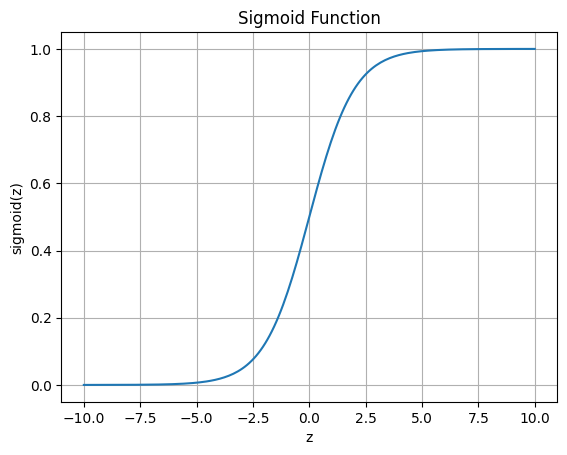

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Generate input values
z = np.linspace(-10, 10, 200)

# Apply sigmoid
y = sigmoid(z)

# Plot graph
plt.figure()
plt.plot(z, y)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)

plt.show()

In [4]:
class Layer:
    def __init__(self, n_neurons, n_inputs):
        self.neurons = [Neuron(n_inputs) for _ in range(n_neurons)]

    def forward(self, inputs):
        return [neuron.forward(inputs) for neuron in self.neurons]

    def __repr__(self):
        return f"Layer({len(self.neurons)} neurons)"

l = Layer(n_neurons=4, n_inputs=2) 
print("Layer:", l)

print("Forward output (4 values):", [round(x, 4) for x in l.forward([0, 1])])

Layer: Layer(4 neurons)
Forward output (4 values): [0.7524, 0.4168, 0.6399, 0.4646]


In [5]:
class NeuralNetwork:
    def __init__(self, layer_sizes):
        # [2, 4, 1] 
        self.layers = []
        for i in range(1, len(layer_sizes)):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i-1]))

    def forward(self, inputs):
        for layer in self.layers:
            inputs = layer.forward(inputs)
        return inputs


In [6]:
net = NeuralNetwork([2, 4, 1])
print(net.forward([0, 1]))

[0.7463095817084614]


In [7]:
xor_data = [
    ([0, 0], [0]),
    ([0, 1], [1]),
    ([1, 0], [1]),
    ([1, 1], [0]),
]

print("XOR Truth Table:")
print("-" * 30)
print(f"{'Input':<15} {'Expected Output'}")
print("-" * 30)
for inputs, expected in xor_data:
    print(f"{str(inputs):<15} {expected[0]}")

XOR Truth Table:
------------------------------
Input           Expected Output
------------------------------
[0, 0]          0
[0, 1]          1
[1, 0]          1
[1, 1]          0


In [8]:
def compute_loss(net, data):
    """
    Mean Squared Error — average squared difference
    between predictions aur actual values.
    """
    total = 0.0
    for inputs, expected in data:
        outputs = net.forward(inputs)
        total  += sum((e - o) ** 2 for e, o in zip(expected, outputs))
    return total / len(data)

# Untrained network ki loss
random.seed(42)
net = NeuralNetwork([2, 4, 1])
initial_loss = compute_loss(net, xor_data)
print(f"Initial loss (untrained): {initial_loss:.6f}")

Initial loss (untrained): 0.308085


In [9]:
class NeuralNetwork:
    """
    Full neural network — multiple layers.
    layer_sizes example: [2, 4, 1]
      → Layer 1: 4 neurons, each taking 2 inputs
      → Layer 2: 1 neuron,  taking 4 inputs
    """

    def __init__(self, layer_sizes):
        self.layers = []
        for i in range(1, len(layer_sizes)):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i - 1]))

    # ──────────────────────────────────────
    # FORWARD PASS
    # ──────────────────────────────────────
    def forward(self, inputs):
        """
        Data left se right flow karta hai.
        Ek layer ka output, next layer ka input.
        """
        for layer in self.layers:
            inputs = layer.forward(inputs)
        return inputs

    # ──────────────────────────────────────
    # BACKWARD PASS (Backpropagation)
    # ──────────────────────────────────────
    def backward(self, expected):
    
        # --- Step 1: Output layer ka delta ---
        output_layer = self.layers[-1]
        for j, neuron in enumerate(output_layer.neurons):
            error        = expected[j] - neuron.output   # kitna galat?
            neuron.delta = error * neuron.sigmoid_deriv(neuron.output)

        # --- Step 2: Hidden layers — peeche propagate karo ---
        for i in reversed(range(len(self.layers) - 1)):
            layer      = self.layers[i]
            next_layer = self.layers[i + 1]
            for j, neuron in enumerate(layer.neurons):
                # Agla layer ka weighted sum of deltas
                error        = sum(nxt.weights[j] * nxt.delta for nxt in next_layer.neurons)
                neuron.delta = error * neuron.sigmoid_deriv(neuron.output)

    # ──────────────────────────────────────
    # WEIGHT UPDATE (Gradient Descent)
    # ──────────────────────────────────────
    def update_weights(self, inputs, lr=0.5):
        for i, layer in enumerate(self.layers):
        
            ins = inputs if i == 0 else [n.output for n in self.layers[i - 1].neurons]
            for neuron in layer.neurons:
                for k in range(len(neuron.weights)):
                    neuron.weights[k] += lr * neuron.delta * ins[k]
                neuron.bias += lr * neuron.delta

    def __repr__(self):
        sizes = [len(self.layers[0].neurons[0].weights)]  # input size
        sizes += [len(l.neurons) for l in self.layers]
        return f"NeuralNetwork(architecture={sizes})"


# Build our XOR network
random.seed(42)
net = NeuralNetwork([2, 4, 1])
print(net)
print("\nUntrained prediction on [0, 1]:", net.forward([0, 1]))

NeuralNetwork(architecture=[2, 4, 1])

Untrained prediction on [0, 1]: [0.2590519455645617]


In [10]:
# Ek forward + backward pass manually chalate hain
random.seed(42)
net = NeuralNetwork([2, 4, 1])

sample_input    = [0, 1]
sample_expected = [1]

# Forward
output = net.forward(sample_input)
print(f"Input: {sample_input}  |  Expected: {sample_expected[0]}  |  Predicted: {round(output[0], 4)}")
print(f"Loss on this example: {(sample_expected[0] - output[0])**2:.6f}")

# Backward
net.backward(sample_expected)

print("\nDeltas after backward pass:")
for i, layer in enumerate(net.layers):
    name = "Hidden" if i < len(net.layers) - 1 else "Output"
    deltas = [round(n.delta, 6) for n in layer.neurons]
    print(f"  Layer {i+1} ({name}): {deltas}")
print("\n(Non-zero deltas = gradients computed )")

Input: [0, 1]  |  Expected: 1  |  Predicted: 0.2591
Loss on this example: 0.549004

Deltas after backward pass:
  Layer 1 (Hidden): [-0.021372, -0.018139, 0.008451, 0.002964]
  Layer 2 (Output): [0.142221]

(Non-zero deltas = gradients computed )


In [11]:
def train(net, data, epochs=10000, lr=0.5, print_every=1000):
    """
    Full training loop:
    1. Forward pass
    2. Compute loss
    3. Backward pass (gradients)
    4. Update weights
    5. Repeat!
    """
    loss_history = []

    for epoch in range(epochs + 1):
        total_loss = 0.0

        for inputs, expected in data:
            # Step 1 — Forward pass
            output      = net.forward(inputs)
            # Step 2 — Accumulate loss
            total_loss += sum((e - o) ** 2 for e, o in zip(expected, output))
            # Step 3 — Backward pass
            net.backward(expected)
            # Step 4 — Update weights
            net.update_weights(inputs, lr)

        loss_history.append(total_loss)

        if epoch % print_every == 0:
            print(f"Epoch {epoch:6d}  |  Loss: {total_loss:.6f}")

    return loss_history


# Train!
random.seed(42)
net = NeuralNetwork([2, 4, 1])

print("Training started...")
print("-" * 35)
history = train(net, xor_data, epochs=10000, lr=0.5, print_every=1000)
print("-" * 35)
print(f"\nFinal loss: {history[-1]:.6f}")
print(f"Loss reduction: {history[0]:.4f} → {history[-1]:.6f} ")

Training started...
-----------------------------------
Epoch      0  |  Loss: 1.248631
Epoch   1000  |  Loss: 0.041095
Epoch   2000  |  Loss: 0.009072
Epoch   3000  |  Loss: 0.004805
Epoch   4000  |  Loss: 0.003215
Epoch   5000  |  Loss: 0.002398
Epoch   6000  |  Loss: 0.001905
Epoch   7000  |  Loss: 0.001576
Epoch   8000  |  Loss: 0.001342
Epoch   9000  |  Loss: 0.001166
Epoch  10000  |  Loss: 0.001031
-----------------------------------

Final loss: 0.001031
Loss reduction: 1.2486 → 0.001031 


In [12]:
def plot_loss_ascii(history, width=60, height=15):
    # Sample evenly spaced points
    step   = max(1, len(history) // width)
    values = [history[i] for i in range(0, len(history), step)][:width]
    max_v  = max(values)
    min_v  = min(values)
    rng    = max_v - min_v or 1

    # Normalize to height
    rows = []
    for row in range(height):
        threshold = max_v - (row / (height - 1)) * rng
        line = ""
        for v in values:
            line += "█" if v >= threshold else " "
        rows.append(line)

    print(f"  Loss Curve ({len(history)} epochs)")
    print(f"  {max_v:.3f} ┤")
    for i, row in enumerate(rows):
        print(f"        │{row}│")
    print(f"  {min_v:.4f} ┤")
    print(f"        └{'─'*width}┘")
    print(f"         Epoch 0{' '*(width-14)}Epoch {len(history)}")

plot_loss_ascii(history)

  Loss Curve (10001 epochs)
  1.249 ┤
        │█                                                           │
        │█                                                           │
        │█                                                           │
        │██                                                          │
        │███                                                         │
        │███                                                         │
        │███                                                         │
        │███                                                         │
        │████                                                        │
        │████                                                        │
        │████                                                        │
        │████                                                        │
        │█████                                                       │
        │█████                         

In [13]:
print("Testing trained network on XOR:")
print("=" * 50)
print(f"{'Input':<12} {'Predicted':>12} {'Expected':>10} {'Result':>8}")
print("-" * 50)

all_correct = True
for inputs, expected in xor_data:
    pred      = net.forward(inputs)[0]
    predicted = round(pred)
    correct   = predicted == expected[0]
    status    = "yes" if correct else "no"
    if not correct:
        all_correct = False
    print(f"{str(inputs):<12} {pred:>12.4f} {expected[0]:>10}      {status}")

print("=" * 50)
if all_correct:
    print("\nPREDICTIONS CORRECT!")
else:
    print("\n predictions wrong")

Testing trained network on XOR:
Input           Predicted   Expected   Result
--------------------------------------------------
[0, 0]             0.0092          0      yes
[0, 1]             0.9857          1      yes
[1, 0]             0.9841          1      yes
[1, 1]             0.0221          0      yes

PREDICTIONS CORRECT!


@ Akansha Yadav